In [14]:
import numpy as np
import pandas as pd
import plotly.express as px
import re

In [15]:
pd.set_option('display.max_columns', None)

In [16]:
df = pd.read_parquet("/Users/aniket/TU_Eindhoven/2_Study/Q4_2AMV10_Visual_Analytics/4_Code/2_AMV10_Visual_Analytics/processed_data/movies_data_updated.parquet")
df

,movieId,imdbId,tmdbId,imdb_id,title,original_language,overview,tagline,release_date,release_year,release_month,release_decade,movie_age,is_recent,runtime,runtime_bin,is_short_film,is_feature_film,is_long_film,status,adult,homepage,poster_url,collection_name,budget,revenue,profit,roi,log_budget,log_revenue,log_profit,vote_average,vote_count,vote_min,vote_max,popularity,popularity_score,critical_success,crowd_approval,genre_list,main_genre,genre_count,keywords,keyword_count,tag,tag_count,director,director_popularity,producer,producer_popularity,lead_actor,lead_actor_popularity,lead_actor_genre_diversity,other_lead,other_lead_popularity,other_lead_genre_diversity,other_actors,spoken_language_names,main_language,has_translation,production_country_names,main_country,production_company_names,main_production_company,company_popularity,franchise_strength
0,1,114709,862,tt0114709,Toy Story,en,"Led by Woody, Andy's toys live happily in his ...",None,1995-10-30,1995.0,10.0,1990.0,30.0,0,81.0,60–90min,False,True,False,Released,False,http://toystory.disney.com/toy-story,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,Toy Story Collection,30000000,373554033.0,343554033.0,11.451801,17.216708,19.738573,19.654855,3.886649,68469.0,0.5,5.0,21.946943,43.274542,23.580595,43.274542,"[Adventure, Animation, Children, Comedy, Famil...",Animation,6,"[jealousy, toy, boy, friendship, friends, riva...",9,"[Animation, light hearted, ya boy, itaege, cut...",138,John Lasseter,0.107143,Bonnie Arnold,0.042254,Tom Hanks,0.440860,19.0,Annie Potts,0.165714,9.0,"[Tim Allen, Don Rickles, Jim Varney]",[English],English,[],[United States of America],United States of America,[Pixar Animation Studios],Pixar Animation Studios,0.177431,0.271092
1,2,113497,8844,tt0113497,Jumanji,en,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,1995-12-15,1995.0,12.0,1990.0,30.0,0,104.0,90–120min,False,True,False,Released,False,None,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,None,65000000,262797249.0,197797249.0,3.043035,17.989898,19.386893,19.102753,3.246583,27143.0,0.5,5.0,17.015539,33.144077,18.195330,33.144077,"[Adventure, Children, Family, Fantasy]",Adventure,4,"[board game, disappearance, based on children'...",6,"[magic board game, see also:Zathura, childish,...",49,Joe Johnston,0.107143,Scott Kroopf,0.126761,Robin Williams,0.440860,20.0,Kirsten Dunst,0.111130,18.0,"[Jonathan Hyde, Bradley Pierce, Bonnie Hunt]","[English, Francais]",English,[Francais],[United States of America],United States of America,"[TriStar Pictures, Teitler Film, Interscope Co...",TriStar Pictures,0.214557,NaN
2,3,113228,15602,tt0113228,Grumpier Old Men,en,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,1995-12-22,1995.0,12.0,1990.0,30.0,0,101.0,90–120min,False,True,False,Released,False,None,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,Grumpy Old Men Collection,0,0.0,0.0,NaN,0.000000,0.000000,0.000000,3.173981,15585.0,0.5,5.0,11.7129,30.642024,16.908003,30.642024,"[Comedy, Romance]",Romance,2,"[fishing, best friend, duringcreditsstinger, o...",4,"[fishing, Funniest Movies, Sophia Loren, seque...",25,Howard Deutch,0.119048,None,NaN,Walter Matthau,0.247312,9.0,Ann-Margret,0.110999,13.0,"[Jack Lemmon, Sophia Loren, Daryl Hannah]",[English],English,[],[United States of America],United States of America,"[Warner Bros., Lancaster Gate]",Warner Bros.,0.421683,0.143885
3,4,114885,31357,tt0114885,Waiting to Exhale,en,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,1995-12-22,1995.0,12.0,1990.0,30.0,0,127.0,120–150min,False,False,True,Released,False,None,https://image.tmdb.org/t/p/w500/16XOMpEaLWkrcP...,None,16000000,81452156.0,65452156.0,4.090760,16.588099,18.215526,17.996830,2.874540,2989.0,0.5,5.0,3.859495,23.005026,12.939783,23.005026,"[Comedy, Drama, Romance]",Comedy,3,"[based on novel, interracial relationship, sin...",5,"[girl movie, chick flick, in

In [20]:
df.loc[(df["budget"]!=0) & (~(df["budget"].isna()))]["budget"].unique()

array([30000000, 65000000, 16000000, ...,  3417000, 25868826,  1254040],
      shape=(1221,))

In [23]:
[x for x in df.columns if "rat" in x]

[]

In [17]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46898 entries, 0 to 46897
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   movieId                     46898 non-null  int64         
 1   imdbId                      46898 non-null  int64         
 2   tmdbId                      46898 non-null  int64         
 3   imdb_id                     46881 non-null  object        
 4   title                       46898 non-null  object        
 5   original_language           46887 non-null  object        
 6   overview                    45906 non-null  object        
 7   tagline                     20905 non-null  object        
 8   release_date                46810 non-null  datetime64[ns]
 9   release_year                46848 non-null  float64       
 10  release_month               46810 non-null  float64       
 11  release_decade              46848 non-null  float64   

In [ ]:
df["runtime"] = pd.to_numeric(df["runtime"], errors="coerce")

# bin_edges = [0, 15, 30, 60, 90, 120, 150, float("inf")]
# bin_labels = ["0–15min", "15–30min", "30–60min", "60–90min", "90–120min", "120–150min", "150+min"]

# df["runtime_bin"] = pd.cut(df["runtime"], bins=bin_edges, labels=bin_labels, right=False)

bin_edges = list(range(0, 181, 15)) + [float("inf")]
bin_labels = [f"{i}–{i+15}min" for i in range(0, 180, 15)] + [">180min"]

df["runtime_bin"] = pd.cut(df["runtime"], bins=bin_edges, labels=bin_labels, right=False)

In [5]:
def extract_first_float(x):
    if isinstance(x, str):
        match = re.search(r"\d+\.\d+", x)
        return float(match.group()) if match else None
    return x

# Convert and clean data
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")
df["roi"] = pd.to_numeric(df["roi"], errors="coerce")
df["popularity"] = df["popularity"].apply(extract_first_float)

# Drop rows with missing critical values
df_cleaned = df.dropna(subset=["budget", "roi", "popularity", "main_genre"])

# Plot
fig = px.scatter(
    df_cleaned,
    x="budget",
    y="roi",
    color="main_genre",
    size="popularity",
    hover_data=["title", "release_year", "profit"],
    log_x=True,
    title="ROI vs. Budget (Bubble Size: Popularity, Color: Genre)",
)
fig.show()


In [6]:
df["popularity"] = df["popularity"].apply(extract_first_float)

genre_decade = df.groupby(["release_decade", "main_genre"]).agg(
    avg_popularity=("popularity", "mean")
).reset_index()

fig = px.line(
    genre_decade,
    x="release_decade",
    y="avg_popularity",
    color="main_genre",
    markers=True,
    title="Genre Popularity Over Decades"
)
fig.show()


In [7]:
top_directors = df.groupby("director").agg(
    avg_score=("critical_success", "mean"),
    film_count=("movieId", "count")
).reset_index().sort_values("avg_score", ascending=False).head(20)

fig = px.bar(
    top_directors,
    x="director",
    y="avg_score",
    color="film_count",
    title="Top 20 Directors by Average Critical Success",
    hover_data=["film_count"],
)
fig.show()


In [8]:
actor_diversity = df[["lead_actor", "lead_actor_genre_diversity"]].drop_duplicates()
top_diverse_actors = actor_diversity.sort_values("lead_actor_genre_diversity", ascending=False).head(15)

fig = px.bar(
    top_diverse_actors,
    x="lead_actor",
    y="lead_actor_genre_diversity",
    title="Top 15 Most Genre-Diverse Lead Actors",
    labels={"lead_actor_genre_diversity": "Genre Diversity"}
)
fig.show()


In [9]:
genre_runtime = df.groupby(["main_genre", "runtime_bin"]).size().reset_index(name="count")

fig = px.density_heatmap(
    genre_runtime,
    x="runtime_bin",
    y="main_genre",
    z="count",
    color_continuous_scale="Viridis",
    title="Heatmap of Genre vs. Runtime Bin"
)
fig.show()


/var/folders/6y/x9npfhwj7jg8y0qjzvn6wpb80000gq/T/ipykernel_88120/3957650203.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [10]:
genre_runtime = df.groupby(["main_genre", "runtime_bin"]).size().reset_index(name="count")

genre_totals = genre_runtime.groupby("main_genre")["count"].transform("sum")
genre_runtime["percent"] = genre_runtime["count"] / genre_totals * 100

fig = px.density_heatmap(
    genre_runtime,
    x="runtime_bin",
    y="main_genre",
    z="percent",
    color_continuous_scale="Viridis",
    title="Normalized Heatmap: % of Movies per Runtime Bin (per Genre)"
)
fig.show()


/var/folders/6y/x9npfhwj7jg8y0qjzvn6wpb80000gq/T/ipykernel_88120/2560266750.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [11]:
from sklearn.model_selection import train_test_split

df_balanced = (
    df.groupby("main_genre", group_keys=False)
      .apply(lambda x: x.sample(min(len(x), 500), random_state=42))
)


/var/folders/6y/x9npfhwj7jg8y0qjzvn6wpb80000gq/T/ipykernel_88120/1424667027.py:5: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [12]:
df_grouped = df.groupby(["runtime_bin", "main_genre"]).agg(
    avg_revenue=("revenue", "mean"),
    avg_vote=("vote_average", "mean")
).reset_index()

fig = px.bar(
    df_grouped,
    x="runtime_bin",
    y="avg_vote",
    color="main_genre",
    barmode="group",
    title="Avg Vote by Runtime and Genre"
)
fig.show()


/var/folders/6y/x9npfhwj7jg8y0qjzvn6wpb80000gq/T/ipykernel_88120/2563829980.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
df.loc[df["main_genre"] == "Action"]["vote_average"]

5        3.844211
7        3.122482
8        3.007530
14       2.730977
19       2.894483
           ...   
46809    6.500000
46848    1.000000
46854    5.000000
46862    3.700000
46889    3.800000
Name: vote_average, Length: 4617, dtype: float64

In [ ]:
df["vote_average"]

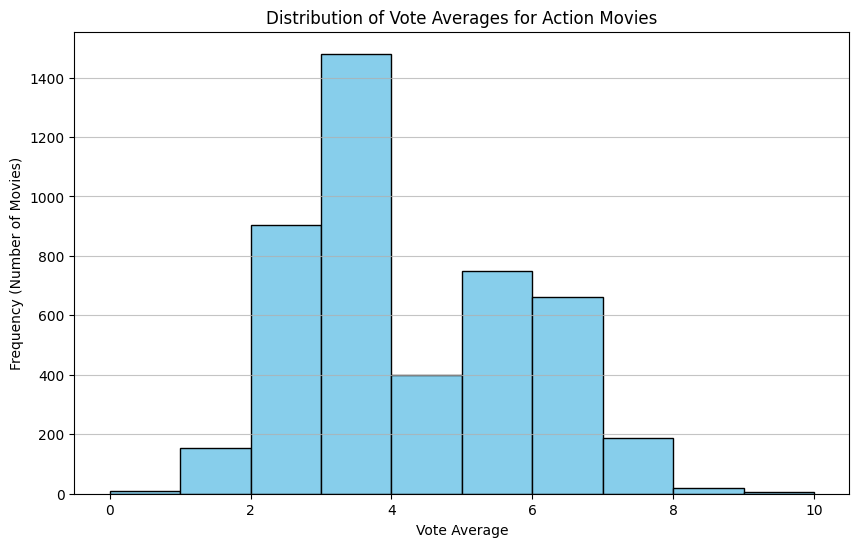

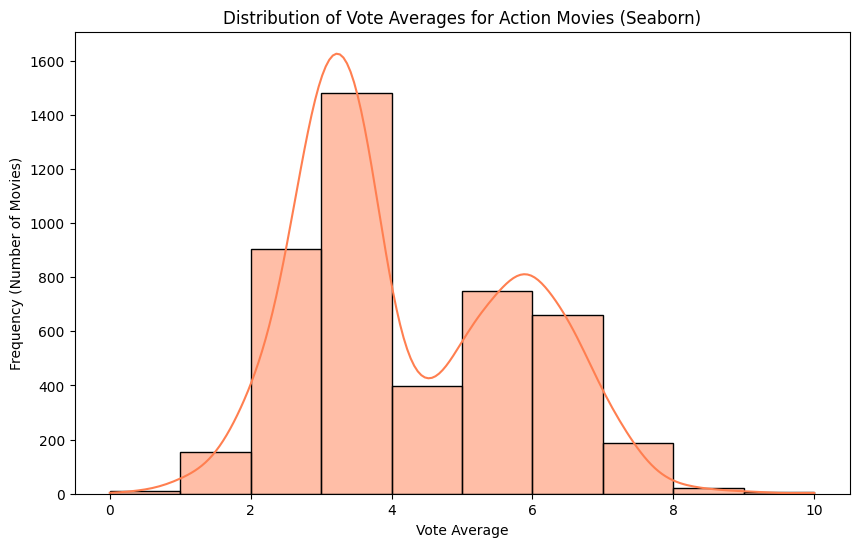

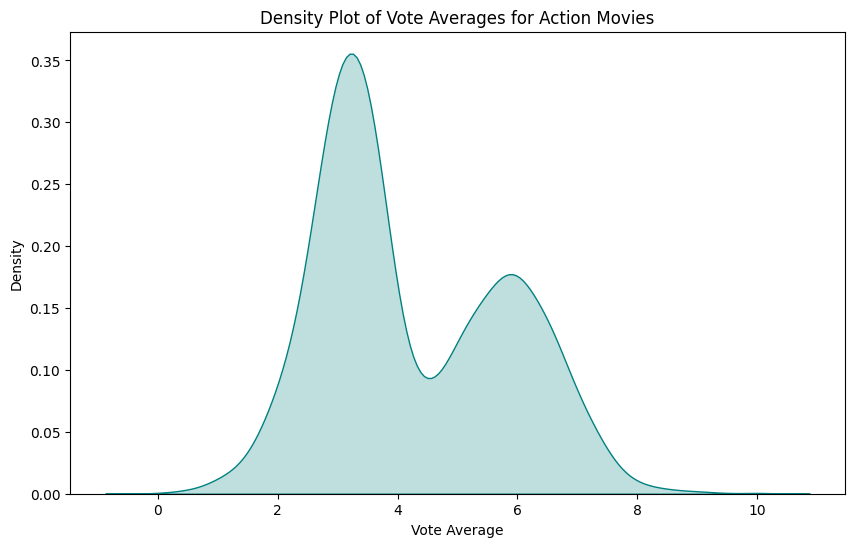

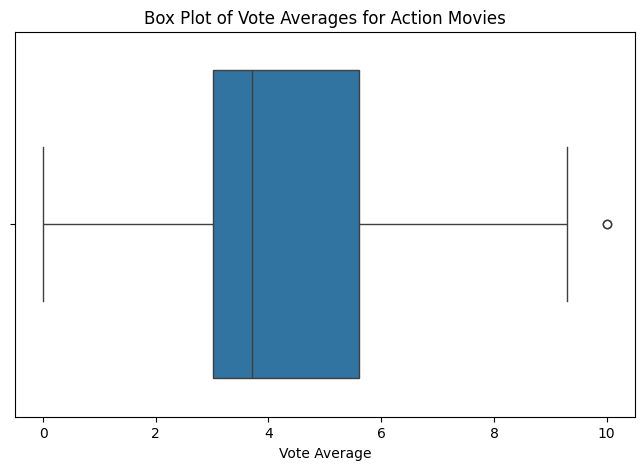

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Assuming you're using pandas for df

# Assuming your DataFrame 'df' is already loaded
# For example:
# data = {'main_genre': ['Action', 'Comedy', 'Action', 'Drama', 'Action'],
#         'vote_average': [7.5, 6.2, 8.1, 7.0, 6.8]}
# df = pd.DataFrame(data)

# This is your code to select the numeric column:
action_vote_averages = df.loc[df["main_genre"] == "Action"]["vote_average"]

# --- Method 1: Using Matplotlib ---
plt.figure(figsize=(10, 6)) # You can adjust the figure size
plt.hist(action_vote_averages, bins=10, color='skyblue', edgecolor='black') # Adjust number of bins as needed
plt.title('Distribution of Vote Averages for Action Movies')
plt.xlabel('Vote Average')
plt.ylabel('Frequency (Number of Movies)')
plt.grid(axis='y', alpha=0.75)
plt.show()

# --- Method 2: Using Seaborn (often preferred for statistical plots) ---
# Seaborn can provide more aesthetically pleasing plots and additional features like KDE.
plt.figure(figsize=(10, 6))
sns.histplot(action_vote_averages, kde=True, bins=10, color='coral') # kde=True adds a Kernel Density Estimate line
plt.title('Distribution of Vote Averages for Action Movies (Seaborn)')
plt.xlabel('Vote Average')
plt.ylabel('Frequency (Number of Movies)')
plt.show()

# If you want to see the distribution as a density plot instead of a histogram:
plt.figure(figsize=(10, 6))
sns.kdeplot(action_vote_averages, fill=True, color='teal')
plt.title('Density Plot of Vote Averages for Action Movies')
plt.xlabel('Vote Average')
plt.ylabel('Density')
plt.show()

# --- Method 3: Using a Box Plot to see quartiles and outliers ---
plt.figure(figsize=(8, 5))
sns.boxplot(x=action_vote_averages)
plt.title('Box Plot of Vote Averages for Action Movies')
plt.xlabel('Vote Average')
plt.show()

In [29]:
len(df["lead_actor"].unique())

18368

In [30]:
df.shape

(46898, 66)

In [31]:
46898/18368

2.5532447735191637

In [32]:
actor_appearances = df.groupby('lead_actor').size()

# For better readability, you can rename the resulting Series
actor_appearances = actor_appearances.rename('appearance_count')

# And sort it, for example, by the count in descending order
actor_appearances_sorted = actor_appearances.sort_values(ascending=False)

# Print the result (which is a Pandas Series)
print("Number of appearances by lead actor (as a Series):")
print(actor_appearances_sorted)

# If you prefer the result as a DataFrame:
actor_appearances_df = actor_appearances_sorted.reset_index()
# Or more directly:
# actor_appearances_df = df.groupby('lead_actor').size().reset_index(name='appearance_count').sort_values('appearance_count', ascending=False)

print("\nNumber of appearances by lead actor (as a DataFrame):")
print(actor_appearances_df)

Number of appearances by lead actor (as a Series):
lead_actor
John Wayne          94
Petteri Summanen    82
Jackie Chan         73
Burt Lancaster      62
Nicolas Cage        60
                    ..
James Carville       1
James Coco           1
James Comey          1
James Craig          1
조병만                  1
Name: appearance_count, Length: 18367, dtype: int64

Number of appearances by lead actor (as a DataFrame):
             lead_actor  appearance_count
0            John Wayne                94
1      Petteri Summanen                82
2           Jackie Chan                73
3        Burt Lancaster                62
4          Nicolas Cage                60
...                 ...               ...
18362    James Carville                 1
18363        James Coco                 1
18364       James Comey                 1
18365       James Craig                 1
18366               조병만                 1

[18367 rows x 2 columns]


In [33]:
actor_appearances_df

,lead_actor,appearance_count
0,John Wayne,94
1,Petteri Summanen,82
2,Jackie Chan,73
3,Burt Lancaster,62
4,Nicolas Cage,60
...,...,...
18362,James Carville,1
18363,James Coco,1
18364,James Comey,1
18365,James Craig,1


In [36]:
actor_appearances_df["appearance_count"].unique()

array([94, 82, 73, 62, 60, 58, 57, 55, 53, 50, 47, 46, 45, 44, 43, 42, 41,
       40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24,
       23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,
        6,  5,  4,  3,  2,  1])

In [39]:
df.sample(75).to_csv("sample_movies_data.csv", index = False)

In [40]:
df.columns

Index(['movieId', 'imdbId', 'tmdbId', 'imdb_id', 'title', 'original_language',
       'overview', 'tagline', 'release_date', 'release_year', 'release_month',
       'release_decade', 'movie_age', 'is_recent', 'runtime', 'runtime_bin',
       'is_short_film', 'is_feature_film', 'is_long_film', 'status', 'adult',
       'homepage', 'poster_url', 'collection_name', 'budget', 'revenue',
       'profit', 'roi', 'log_budget', 'log_revenue', 'log_profit',
       'vote_average', 'vote_count', 'vote_min', 'vote_max', 'popularity',
       'popularity_score', 'critical_success', 'crowd_approval', 'genre_list',
       'main_genre', 'genre_count', 'keywords', 'keyword_count', 'tag',
       'tag_count', 'director', 'director_popularity', 'producer',
       'producer_popularity', 'lead_actor', 'lead_actor_popularity',
       'lead_actor_genre_diversity', 'other_lead', 'other_lead_popularity',
       'other_lead_genre_diversity', 'other_actors', 'spoken_language_names',
       'main_language', 'has_tr

In [41]:
actor_appearances = df.groupby('director').size()

# For better readability, you can rename the resulting Series
actor_appearances = actor_appearances.rename('appearance_count')

# And sort it, for example, by the count in descending order
actor_appearances_sorted = actor_appearances.sort_values(ascending=False)

# Print the result (which is a Pandas Series)
print("Number of appearances by lead actor (as a Series):")
print(actor_appearances_sorted)

# If you prefer the result as a DataFrame:
actor_appearances_df = actor_appearances_sorted.reset_index()
# Or more directly:
# actor_appearances_df = df.groupby('lead_actor').size().reset_index(name='appearance_count').sort_values('appearance_count', ascending=False)

print("\nNumber of appearances by lead actor (as a DataFrame):")
print(actor_appearances_df)

Number of appearances by lead actor (as a Series):
director
JP Siili                    85
John Ford                   67
Michael Curtiz              65
Frank Capra                 59
Werner Herzog               55
                            ..
Jean-Charles Tacchella       1
Jean-Christophe Dessaint     1
Jean-Christophe Jeauffre     1
Jean-Christophe Klotz        1
진모영                          1
Name: appearance_count, Length: 17568, dtype: int64

Number of appearances by lead actor (as a DataFrame):
                       director  appearance_count
0                      JP Siili                85
1                     John Ford                67
2                Michael Curtiz                65
3                   Frank Capra                59
4                 Werner Herzog                55
...                         ...               ...
17563    Jean-Charles Tacchella                 1
17564  Jean-Christophe Dessaint                 1
17565  Jean-Christophe Jeauffre           

In [42]:
actor_appearances_df["appearance_count"].unique()

array([85, 67, 65, 59, 55, 54, 53, 51, 49, 47, 46, 44, 43, 42, 41, 40, 39,
       38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22,
       21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10,  9,  8,  7,  6,  5,
        4,  3,  2,  1])

In [ ]:
df_ratings = pd.read_parquet("/Users/aniket/TU_Eindhoven/2_Study/Q4_2AMV10_Visual_Analytics/4_Code/2_AMV10_Visual_Analytics/processed_data/ratings_data_extended.parquet")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46898 entries, 0 to 46897
Data columns (total 66 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   movieId                     46898 non-null  int64         
 1   imdbId                      46898 non-null  int64         
 2   tmdbId                      46898 non-null  int64         
 3   imdb_id                     46881 non-null  object        
 4   title                       46898 non-null  object        
 5   original_language           46887 non-null  object        
 6   overview                    45906 non-null  object        
 7   tagline                     20905 non-null  object        
 8   release_date                46810 non-null  datetime64[ns]
 9   release_year                46848 non-null  float64       
 10  release_month               46810 non-null  float64       
 11  release_decade              46848 non-null  float64   

In [44]:
df_ratings.info(memory_usage="deep")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27718143 entries, 0 to 27718142
Data columns (total 9 columns):
 #   Column        Dtype         
---  ------        -----         
 0   userId        int32         
 1   movieId       int32         
 2   rating        float32       
 3   timestamp     datetime64[ns]
 4   title         object        
 5   main_genre    object        
 6   director      object        
 7   lead_actor    object        
 8   release_year  float64       
dtypes: datetime64[ns](1), float32(1), float64(1), int32(2), object(4)
memory usage: 7.1 GB


In [45]:
df_ratings.groupby("userId")

In [46]:
user_rating_counts = df_ratings.groupby("userId").size().reset_index(name="num_ratings")
user_rating_counts

,userId,num_ratings
0,1,16
1,2,15
2,3,11
3,4,741
4,5,72
...,...,...
283107,283224,329
283108,283225,20
283109,283226,11
283110,283227,17


In [49]:
user_rating_counts.loc[user_rating_counts["num_ratings"] == 22939]

,userId,num_ratings
123047,123100,22939


In [47]:
user_rating_counts.describe()

,userId,num_ratings
count,283112.000000,283112.000000
mean,141615.179325,97.905221
std,81760.495184,212.153810
min,1.000000,1.000000
25%,70807.750000,15.000000
50%,141611.500000,30.000000
75%,212422.250000,95.000000
max,283228.000000,22939.000000


In [ ]:
user_rating_counts

In [ ]:
df_ratings.loc[df_ratings[""]]

In [51]:
df["runtime"].sum()

np.float64(4389467.0)

In [52]:
df.shape

(46898, 66)

In [53]:
4389467.0/46898

93.59603821058467

In [54]:
93.59603821058467*22939

2146999.520512602

In [55]:
2146999.520512602//60

35783.0

In [57]:
35783.0//24

1490.0

In [59]:
1490.0//365

4.0

In [60]:
user_rating_counts.loc[user_rating_counts["num_ratings"] == 1]

,userId,num_ratings
8,9,1
32,33,1
168,169,1
197,198,1
219,220,1
...,...,...
282956,283073,1
282971,283088,1
283027,283144,1
283034,283151,1


In [76]:
user_rating_counts.loc[(user_rating_counts["num_ratings"] > 30) & (user_rating_counts["num_ratings"] <= 45)]


,userId,num_ratings
5,6,42
7,8,31
15,16,41
36,37,33
53,54,38
...,...,...
283080,283197,41
283096,283213,31
283097,283214,32
283101,283218,34


In [69]:
len(df_ratings.loc[df_ratings["userId"] == 123100]["movieId"].unique())

22378

In [71]:
22939 - 22378

561

In [68]:
df_ratings

,userId,movieId,rating,timestamp,title,main_genre,director,lead_actor,release_year
0,1,307,3.5,2009-10-27 21:00:21,Three Colors: Blue,Drama,Krzysztof Kieślowski,Juliette Binoche,1993.0
1,1,481,3.5,2009-10-27 21:04:16,Kalifornia,Thriller,Dominic Sena,Brad Pitt,1993.0
2,1,1091,1.5,2009-10-27 21:04:31,Weekend at Bernie's,Comedy,Ted Kotcheff,Andrew McCarthy,1989.0
3,1,1257,4.5,2009-10-27 21:04:20,Better Off Dead...,Comedy,Savage Steve Holland,John Cusack,1985.0
4,1,1449,4.5,2009-10-27 21:01:04,Waiting for Guffman,Music,Christopher Guest,Christopher Guest,1996.0
...,...,...,...,...,...,...,...,...,...
27718138,283228,8542,4.5,2013-09-22 20:46:35,A Day at the Races,Comedy,Sam Wood,Groucho Marx,1937.0
27718139,283228,8712,4.5,2013-09-22 20:45:51,My Favorite Wife,Comedy,Garson Kanin,Cary Grant,1940.0
27718140,283228,34405,4.5,2013-09-22 20:48:09,Serenity,Science Fiction,Joss Whedon,Nathan Fillion,2005.0
27718141,283228,44761,4.5,2012-11-29 03:25:24,Brick,Drama,Rian Johnson,Joseph Gordon-Levitt,2005.0


In [77]:
df["release_year"].min()

np.float64(1874.0)

In [86]:
df.loc[df["release_year"] == 1874]

,movieId,imdbId,tmdbId,imdb_id,title,original_language,overview,tagline,release_date,release_year,release_month,release_decade,movie_age,is_recent,runtime,runtime_bin,is_short_film,is_feature_film,is_long_film,status,adult,homepage,poster_url,collection_name,budget,revenue,profit,roi,log_budget,log_revenue,log_profit,vote_average,vote_count,vote_min,vote_max,popularity,popularity_score,critical_success,crowd_approval,genre_list,main_genre,genre_count,keywords,keyword_count,tag,tag_count,director,director_popularity,producer,producer_popularity,lead_actor,lead_actor_popularity,lead_actor_genre_diversity,other_lead,other_lead_popularity,other_lead_genre_diversity,other_actors,spoken_language_names,main_language,has_translation,production_country_names,main_country,production_company_names,main_production_company,company_popularity,franchise_strength
35371,148054,3155794,315946,tt3155794,Passage of Venus,xx,Photo sequence of the rare transit of Venus ov...,None,1874-12-09,1874.0,12.0,1870.0,151.0,0,1.0,0–30min,True,False,False,Released,False,None,https://image.tmdb.org/t/p/w500/9jtgJphKW836gI...,None,0,0.0,0.0,NaN,0.0,0.0,0.0,6.0,19.0,0.5,5.0,0.480371,17.974394,11.987197,17.974394,[Documentary],Documentary,1,"[silent film, science, astronomy, venus the pl...",5,"[astronomy, venus the planet, silent film, Dir...",7,P.J.C. Janssen,0.0,None,NaN,None,NaN,NaN,None,NaN,NaN,[],[No Language],No Language,[],[France],France,[],None,NaN,NaN


In [79]:
1874+151

2025

In [87]:
df

,movieId,imdbId,tmdbId,imdb_id,title,original_language,overview,tagline,release_date,release_year,release_month,release_decade,movie_age,is_recent,runtime,runtime_bin,is_short_film,is_feature_film,is_long_film,status,adult,homepage,poster_url,collection_name,budget,revenue,profit,roi,log_budget,log_revenue,log_profit,vote_average,vote_count,vote_min,vote_max,popularity,popularity_score,critical_success,crowd_approval,genre_list,main_genre,genre_count,keywords,keyword_count,tag,tag_count,director,director_popularity,producer,producer_popularity,lead_actor,lead_actor_popularity,lead_actor_genre_diversity,other_lead,other_lead_popularity,other_lead_genre_diversity,other_actors,spoken_language_names,main_language,has_translation,production_country_names,main_country,production_company_names,main_production_company,company_popularity,franchise_strength
0,1,114709,862,tt0114709,Toy Story,en,"Led by Woody, Andy's toys live happily in his ...",None,1995-10-30,1995.0,10.0,1990.0,30.0,0,81.0,60–90min,False,True,False,Released,False,http://toystory.disney.com/toy-story,https://image.tmdb.org/t/p/w500/rhIRbceoE9lR4v...,Toy Story Collection,30000000,373554033.0,343554033.0,11.451801,17.216708,19.738573,19.654855,3.886649,68469.0,0.5,5.0,21.946943,43.274542,23.580595,43.274542,"[Adventure, Animation, Children, Comedy, Famil...",Animation,6,"[jealousy, toy, boy, friendship, friends, riva...",9,"[Animation, light hearted, ya boy, itaege, cut...",138,John Lasseter,0.107143,Bonnie Arnold,0.042254,Tom Hanks,0.440860,19.0,Annie Potts,0.165714,9.0,"[Tim Allen, Don Rickles, Jim Varney]",[English],English,[],[United States of America],United States of America,[Pixar Animation Studios],Pixar Animation Studios,0.177431,0.271092
1,2,113497,8844,tt0113497,Jumanji,en,When siblings Judy and Peter discover an encha...,Roll the dice and unleash the excitement!,1995-12-15,1995.0,12.0,1990.0,30.0,0,104.0,90–120min,False,True,False,Released,False,None,https://image.tmdb.org/t/p/w500/vzmL6fP7aPKNKP...,None,65000000,262797249.0,197797249.0,3.043035,17.989898,19.386893,19.102753,3.246583,27143.0,0.5,5.0,17.015539,33.144077,18.195330,33.144077,"[Adventure, Children, Family, Fantasy]",Adventure,4,"[board game, disappearance, based on children'...",6,"[magic board game, see also:Zathura, childish,...",49,Joe Johnston,0.107143,Scott Kroopf,0.126761,Robin Williams,0.440860,20.0,Kirsten Dunst,0.111130,18.0,"[Jonathan Hyde, Bradley Pierce, Bonnie Hunt]","[English, Francais]",English,[Francais],[United States of America],United States of America,"[TriStar Pictures, Teitler Film, Interscope Co...",TriStar Pictures,0.214557,NaN
2,3,113228,15602,tt0113228,Grumpier Old Men,en,A family wedding reignites the ancient feud be...,Still Yelling. Still Fighting. Still Ready for...,1995-12-22,1995.0,12.0,1990.0,30.0,0,101.0,90–120min,False,True,False,Released,False,None,https://image.tmdb.org/t/p/w500/6ksm1sjKMFLbO7...,Grumpy Old Men Collection,0,0.0,0.0,NaN,0.000000,0.000000,0.000000,3.173981,15585.0,0.5,5.0,11.7129,30.642024,16.908003,30.642024,"[Comedy, Romance]",Romance,2,"[fishing, best friend, duringcreditsstinger, o...",4,"[fishing, Funniest Movies, Sophia Loren, seque...",25,Howard Deutch,0.119048,None,NaN,Walter Matthau,0.247312,9.0,Ann-Margret,0.110999,13.0,"[Jack Lemmon, Sophia Loren, Daryl Hannah]",[English],English,[],[United States of America],United States of America,"[Warner Bros., Lancaster Gate]",Warner Bros.,0.421683,0.143885
3,4,114885,31357,tt0114885,Waiting to Exhale,en,"Cheated on, mistreated and stepped on, the wom...",Friends are the people who let you be yourself...,1995-12-22,1995.0,12.0,1990.0,30.0,0,127.0,120–150min,False,False,True,Released,False,None,https://image.tmdb.org/t/p/w500/16XOMpEaLWkrcP...,None,16000000,81452156.0,65452156.0,4.090760,16.588099,18.215526,17.996830,2.874540,2989.0,0.5,5.0,3.859495,23.005026,12.939783,23.005026,"[Comedy, Drama, Romance]",Comedy,3,"[based on novel, interracial relationship, sin...",5,"[girl movie, chick flick, in